# 245. Shortest Word Distance III
https://leetcode.com/problems/shortest-word-distance-iii/

## Complexity Comparison

| Approach | Time | Space | Description |
|----------|------|-------|-------------|
| **One Pass** | **O(n)** | **O(1)** | **Track last indices, handle same-word case** |

## Methodology

This is a variant of Shortest Word Distance where `word1` and `word2` may be the **same word**. We do a single pass through the array, tracking the last seen index for each word. When word1 == word2, we update by shifting the previous index before recording the new one, ensuring we compare two different occurrences of the same word.

## Solutions

### C#

In [ ]:
// 245. Shortest Word Distance III
// Time: O(n) | Space: O(1)
public class Solution {
    public int ShortestWordDistance(string[] wordsDict, string word1, string word2) {
        int idx1 = -1, idx2 = -1;
        int minDist = int.MaxValue;
        bool same = word1 == word2;
        
        for (int i = 0; i < wordsDict.Length; i++) {
            if (wordsDict[i] == word1) {
                if (same) idx2 = idx1;
                idx1 = i;
            } else if (wordsDict[i] == word2) {
                idx2 = i;
            }
            
            if (idx1 >= 0 && idx2 >= 0)
                minDist = Math.Min(minDist, Math.Abs(idx1 - idx2));
        }
        return minDist;
    }
}

### Python

In [ ]:
# 245. Shortest Word Distance III
# Time: O(n) | Space: O(1)
class Solution:
    def shortestWordDistance(self, wordsDict: list[str], word1: str, word2: str) -> int:
        idx1 = idx2 = -1
        min_dist = float('inf')
        same = word1 == word2
        
        for i, word in enumerate(wordsDict):
            if word == word1:
                if same:
                    idx2 = idx1
                idx1 = i
            elif word == word2:
                idx2 = i
            
            if idx1 >= 0 and idx2 >= 0:
                min_dist = min(min_dist, abs(idx1 - idx2))
        
        return min_dist

### Go

In [ ]:
// 245. Shortest Word Distance III
// Time: O(n) | Space: O(1)
func shortestWordDistance(wordsDict []string, word1 string, word2 string) int {
    idx1, idx2 := -1, -1
    minDist := 1<<31 - 1
    same := word1 == word2
    
    for i, word := range wordsDict {
        if word == word1 {
            if same {
                idx2 = idx1
            }
            idx1 = i
        } else if word == word2 {
            idx2 = i
        }
        
        if idx1 >= 0 && idx2 >= 0 {
            d := idx1 - idx2
            if d < 0 {
                d = -d
            }
            if d < minDist {
                minDist = d
            }
        }
    }
    return minDist
}

### Rust

In [ ]:
// 245. Shortest Word Distance III
// Time: O(n) | Space: O(1)
impl Solution {
    pub fn shortest_word_distance(words_dict: Vec<String>, word1: String, word2: String) -> i32 {
        let (mut idx1, mut idx2) = (-1i32, -1i32);
        let mut min_dist = i32::MAX;
        let same = word1 == word2;
        
        for (i, word) in words_dict.iter().enumerate() {
            if *word == word1 {
                if same { idx2 = idx1; }
                idx1 = i as i32;
            } else if *word == word2 {
                idx2 = i as i32;
            }
            
            if idx1 >= 0 && idx2 >= 0 {
                min_dist = min_dist.min((idx1 - idx2).abs());
            }
        }
        min_dist
    }
}

## Example Scenarios

1. **Common Case** — Two different words  
   **Input:** `wordsDict = ["practice","makes","perfect","coding","makes"], word1 = "makes", word2 = "coding"`  
   "makes" appears at indices $\{1, 4\}$, "coding" at $\{3\}$. Minimum distance $= |3 - 4| = 1$.

2. **Slightly Complex** — Same word (word1 == word2)  
   **Input:** `wordsDict = ["practice","makes","perfect","coding","makes"], word1 = "makes", word2 = "makes"`  
   "makes" at indices $1$ and $4$. When word1 equals word2, we track the previous occurrence and compute $|4 - 1| = 3$. The algorithm shifts idx1 to idx2 before updating.

3. **Edge Case: Time Factor** — Words at opposite ends of a long array  
   **Input:** `wordsDict = ["a","x","x",...,"x","b"]` ($n$ words), word1 = "a", word2 = "b"  
   word1 at index $0$, word2 at index $n-1$. We must scan the entire array — $O(n)$ — to find the only occurrence of each. Distance $= n-1$, the maximum possible.

4. **Edge Case: Space Factor** — All words identical  
   **Input:** `wordsDict = ["a","a","a","a","a"], word1 = "a", word2 = "a"`  
   Every adjacent pair has distance $1$. The algorithm uses $O(1)$ space — only two index variables — regardless of how many occurrences exist. Minimum distance $= 1$.

5. **Almost-Impossible but Plausible** — Maximum constraints  
   **Input:** `wordsDict` has $n = 10^5$ words, each up to $10^3$ characters  
   Single-pass $O(n)$ scan with $O(1)$ space. Even with $10^5$ string comparisons, each up to $10^3$ characters, the total work is $O(10^8)$ character comparisons — tight but feasible within typical time limits.

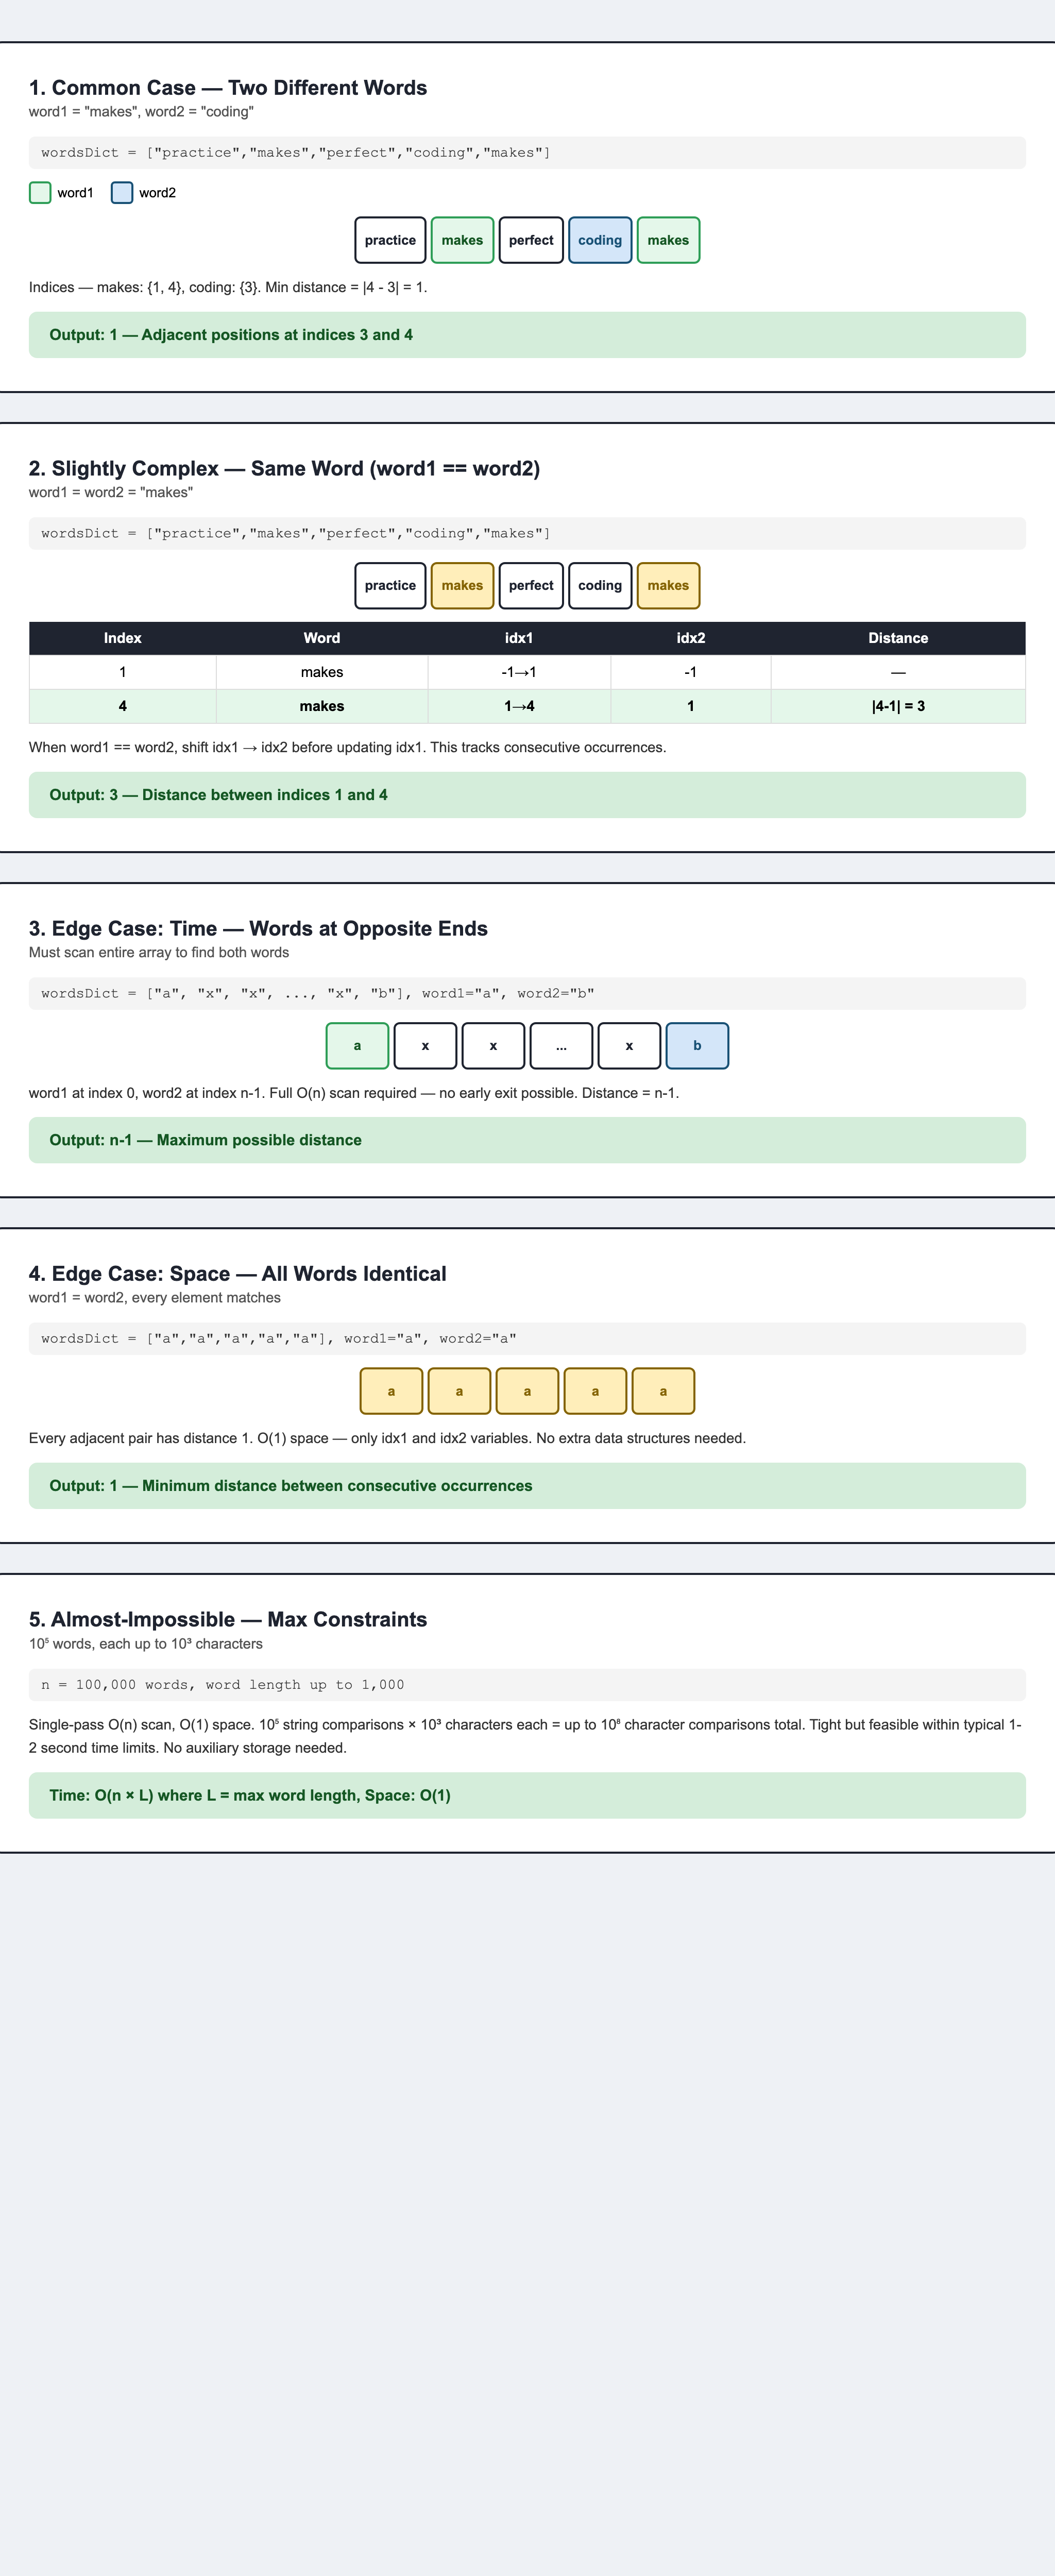